# Proyecto Data Mart — Sakila
**Ana Lucía**, **Mario Wunderlich**

Sección V

**Posgrado en Análisis y Predicción de Datos**
Solución de preguntas analíticas sobre el Gold Layer del Data Mart construido con ClickHouse.

## Configuración de la conexión

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from clickhouse_driver import Client

from config.settings import CLICKHOUSE

client = Client(
    host=CLICKHOUSE["host"],
    port=CLICKHOUSE["port_native"],
    user=CLICKHOUSE["user"],
    password=CLICKHOUSE["password"],
)

def query(sql: str) -> pd.DataFrame:
    result, columns = client.execute(sql, with_column_types=True)
    col_names = [col[0] for col in columns]
    return pd.DataFrame(result, columns=col_names)

---
## A) ¿Cuá es el top 10 de las películas que más se rentan?
Se consulta la tabla `fact_rental` del Gold Layer, agrupando por título de película
y contando el número de rentas registradas.

In [34]:
df_a = query("""
    SELECT
        dim_film.film_title,
        COUNT(*) AS total_rentals
    FROM sakila_gold.fact_rental
    LEFT JOIN sakila_gold.dim_film ON dim_film.film_id = fact_rental.film_id
    GROUP BY film_id, film_title
    ORDER BY total_rentals DESC
    LIMIT 10
""")

df_a

,film_title,total_rentals
0,BUCKET BROTHERHOOD,34
1,ROCKETEER MOTHER,33
2,FORWARD TEMPLE,32
3,SCALAWAG DUCK,32
4,RIDGEMONT SUBMARINE,32
5,GRIT CLOCKWORK,32
6,JUGGLER HARDLY,32
7,HOBBIT ALIEN,31
8,WIFE TURN,31
9,APACHE DIVINE,31


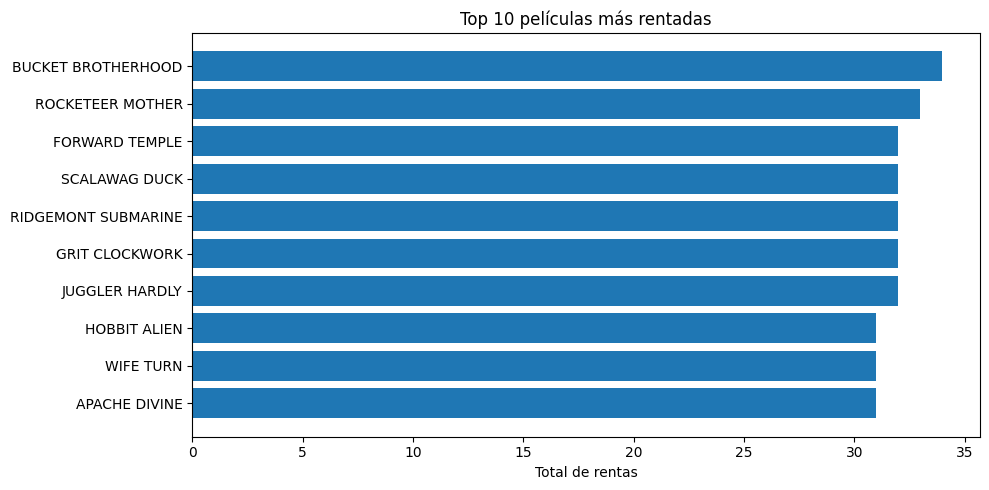

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_a["film_title"][::-1], df_a["total_rentals"][::-1])
ax.set_xlabel("Total de rentas")
ax.set_title("Top 10 películas más rentadas")
plt.tight_layout()
plt.show()

---
## B) ¿Cuál es el país donde más se rentan películas?
Se consulta la tabla `fact_rental` agrupando por país para identificar
cuál genera el mayor volumen de rentas.

In [36]:
df_b = query("""
    SELECT
        dim_customer.country,
        COUNT(*) AS total_rentals
    FROM sakila_gold.fact_rental
    LEFT JOIN sakila_gold.dim_customer ON dim_customer.customer_id = fact_rental.customer_id
    GROUP BY country
    ORDER BY total_rentals DESC
    LIMIT 10
""")

df_b

,country,total_rentals
0,India,1572
1,China,1426
2,United States,968
3,Japan,825
4,Mexico,796
5,Brazil,748
6,Russian Federation,713
7,Philippines,568
8,Turkey,388
9,Indonesia,367


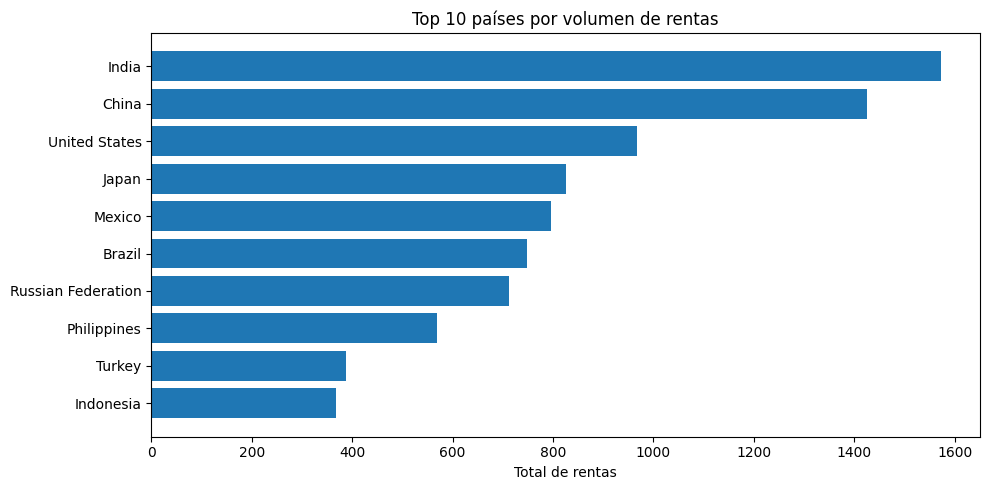

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_b["country"][::-1], df_b["total_rentals"][::-1])
ax.set_xlabel("Total de rentas")
ax.set_title("Top 10 países por volumen de rentas")
plt.tight_layout()
plt.show()

---
## C) ¿Muestre una lista con los montos totales pagados por todos los clientes?
Se consulta la tabla `fact_payment` agrupando por cliente y sumando
el monto total de sus pagos registrados en el sistema.

In [38]:
df_c = query("""
    SELECT
        dim_customer.country,
        dim_customer.full_name AS customer_name,
        SUM(fact_payment.amount) AS total_paid
    FROM sakila_gold.fact_payment
    LEFT JOIN sakila_gold.dim_customer ON dim_customer.customer_id = fact_payment.customer_id
    GROUP BY customer_id, country, customer_name
    ORDER BY total_paid DESC
""")

df_c

,country,customer_name,total_paid
0,United States,KARL SEAL,221.55
1,Réunion,ELEANOR HUNT,216.54
2,Belarus,CLARA SHAW,195.58
3,Netherlands,RHONDA KENNEDY,194.61
4,Brazil,MARION SNYDER,194.61
...,...,...,...
594,Mozambique,ANNIE RUSSELL,58.82
595,Sudan,JOHNNY TURPIN,57.81
596,Poland,BRIAN WYMAN,52.88
597,China,LEONA OBRIEN,50.86


---
## D) ¿Cuál es el actor que más rentas ha registrado?
Se consulta la tabla `fact_actor_rentals` del Gold Layer, la cual ya contiene
el conteo pre-agregado de rentas por actor.

In [47]:
df_d = query("""
    SELECT
        a.full_name,
        ar.total_rentals
    FROM sakila_gold.agg_actor_rentals ar
    JOIN sakila_gold.dim_actor a ON ar.actor_id = a.actor_id
    ORDER BY ar.total_rentals DESC
    LIMIT 10;
""")

df_d

,full_name,total_rentals
0,GINA DEGENERES,753
1,MATTHEW CARREY,678
2,MARY KEITEL,674
3,ANGELA WITHERSPOON,654
4,WALTER TORN,640
5,HENRY BERRY,612
6,JAYNE NOLTE,611
7,VAL BOLGER,605
8,SANDRA KILMER,604
9,SEAN GUINESS,599


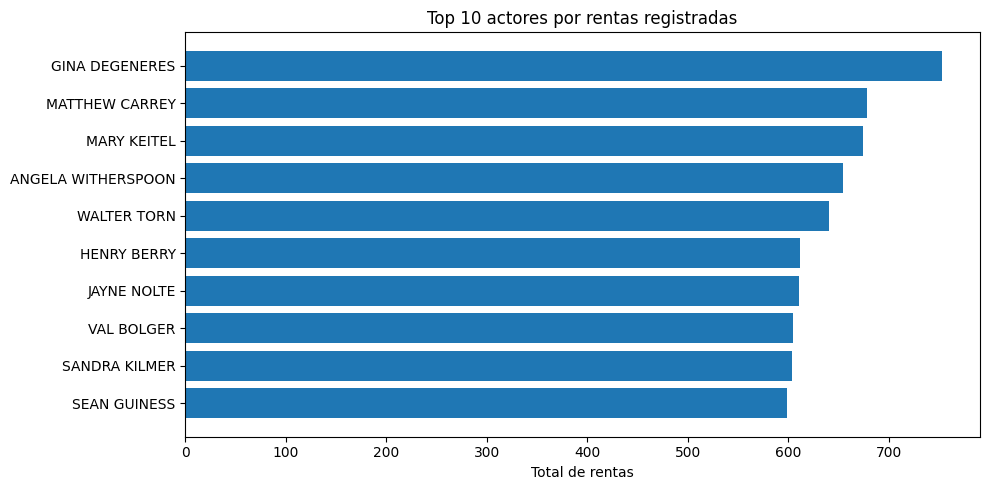

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_d["actor_name"][::-1], df_d["total_rentals"][::-1])
ax.set_xlabel("Total de rentas")
ax.set_title("Top 10 actores por rentas registradas")
plt.tight_layout()
plt.show()

---
## E) Muestre una gráfica de serie temporal de montos cobrados por mes.,
Se consulta la tabla `fact_payment` utilizando la columna `payment_month`
para agrupar los montos cobrados por mes y visualizarlos como serie temporal.

In [41]:
df_e = query("""
    SELECT
        payment_day,
        SUM(amount) AS total_revenue
    FROM sakila_gold.fact_payment
    GROUP BY payment_day
    ORDER BY payment_day ASC
""")

# Convertir payment_month (YYYYMM) a fecha legible
df_e["day_label"] = pd.to_datetime(df_e["payment_day"].astype(str), format="%Y%m%d")

df_e

,payment_day,total_revenue,day_label
0,20050524,29.92,2005-05-24
1,20050525,573.63,2005-05-25
2,20050526,754.26,2005-05-26
3,20050527,684.34,2005-05-27
4,20050528,804.04,2005-05-28
5,20050529,648.46,2005-05-29
6,20050530,628.42,2005-05-30
7,20050531,700.37,2005-05-31
8,20050614,57.84,2005-06-14
9,20050615,1376.52,2005-06-15


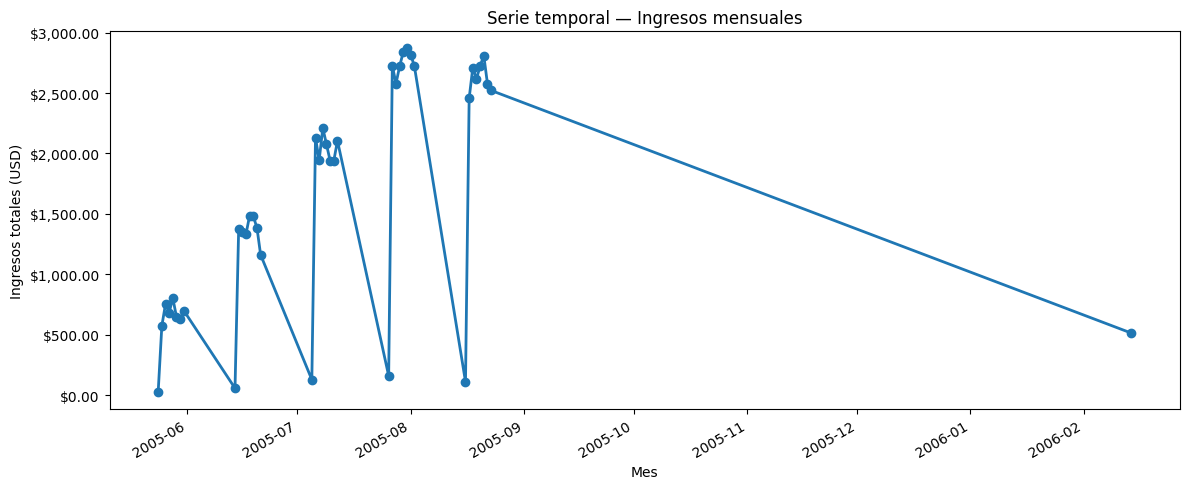

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_e["day_label"], df_e["total_revenue"], marker="o", linewidth=2)
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos totales (USD)")
ax.set_title("Serie temporal — Ingresos mensuales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()